In [1]:
from neuromodes.TEMP_utils import make_vol_mesh, plot_mesh_data, tetmesh_to_nifti
from nibabel.affines import apply_affine
from nibabel.loadsave import load
import numpy as np
from neuromodes import EigenSolver
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from nilearn.plotting import plot_stat_map

neuromodes = 'C:/Users/ipop0003/neuromodes'

In [2]:
# Get NIFTI and make volumetric mesh
niftipath = f'{neuromodes}/TEMP_investigations/hcp_hippo-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)

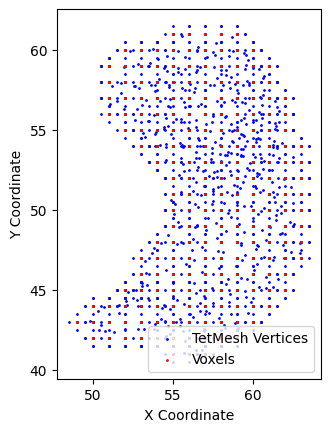

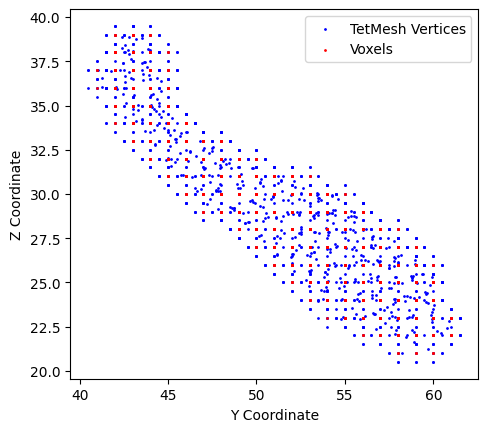

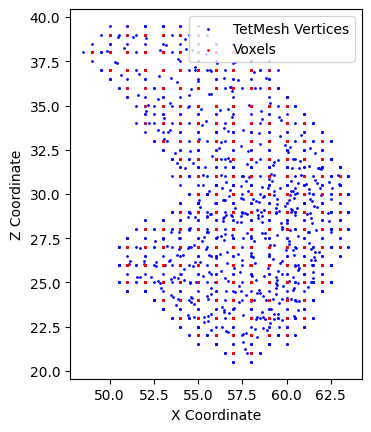

In [4]:
# plot x-y coords of surface and voxels in world space
xyz = np.column_stack(np.where(nifti.get_fdata() > 0))      # (i,j,k) = (z,y,x)
apply_affine(nifti.affine, xyz, inplace=True)       # world space

# Plot vol & mesh
plt.scatter(vol.v[:, 0], vol.v[:, 1], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 0], xyz[:, 1], s=1, color='red', label='Voxels')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

# Same plot but y-z coords
plt.scatter(vol.v[:, 1], vol.v[:, 2], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 1], xyz[:, 2], s=1, color='red', label='Voxels')
plt.xlabel('Y Coordinate')
plt.ylabel('Z Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

# Same plot but x-z coords
plt.scatter(vol.v[:, 0], vol.v[:, 2], s=1, color='blue', label='TetMesh Vertices')
plt.scatter(xyz[:, 0], xyz[:, 2], s=1, color='red', label='Voxels')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()


In [17]:
# Solve eigenmodes on volumetric mesh
solver = EigenSolver(vol).solve(10)

# Visualise tetmesh
plot_mesh_data(vol, solver.emodes[:, 7])

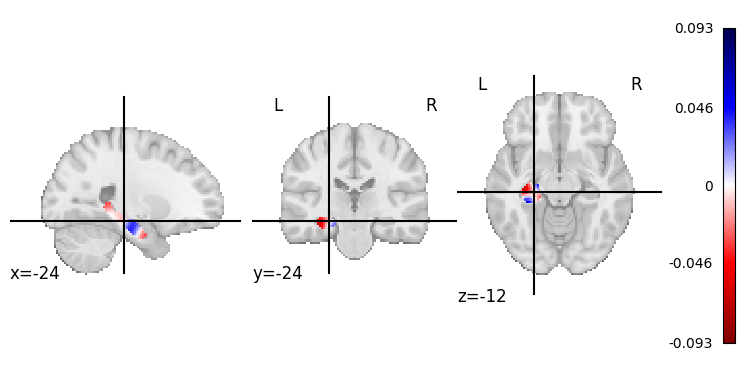

In [18]:
# Try transformation function
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)

plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

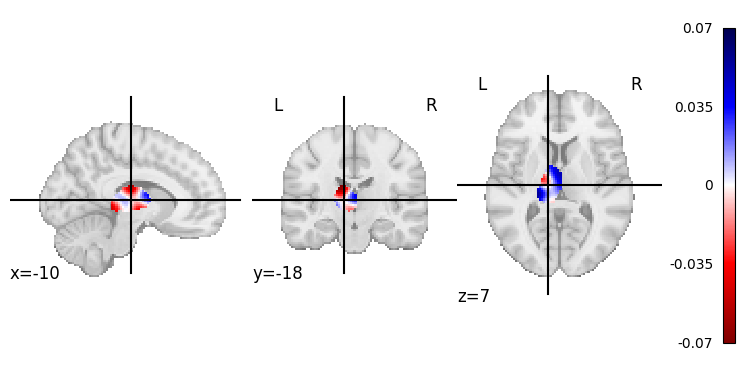

In [2]:
# Try thalamus and striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_tha-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)
solver = EigenSolver(vol).solve(10)
plot_mesh_data(vol, solver.emodes[:, 7])
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

In [20]:
# Try striatum
niftipath = f'{neuromodes}/TEMP_investigations/hcp_striatum-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)
solver = EigenSolver(vol).solve(10)
plot_mesh_data(vol, solver.emodes[:, 7])
mode_nifti = tetmesh_to_nifti(solver.emodes[:, 7], solver.geometry, nifti)
plot_stat_map(mode_nifti, display_mode='ortho', cmap='seismic_r')

ValueError: Surface mesh is not contiguous: 2 connected components found.

In [ ]:
# Striatum isn't working--check_surf before applying affine
from skimage.measure import marching_cubes
from neuromodes.mesh import check_surf, mask_mesh
from lapy import TriaMesh

# Get binary ROI from NIFTI
roi = (nifti.get_fdata() > 0).astype(np.uint8)

# Marching cubes to extract smoothed surface (replacing mri_mc from FreeSurfer)
surf_verts, trias, _, _ = marching_cubes(roi, level=0.5, allow_degenerate=False)
mesh = TriaMesh(v=surf_verts, t=trias)
check_surf(mesh)

ValueError: Surface mesh is not contiguous: 2 connected components found.

In [ ]:
# ok just plot it
plot_mesh_data(mesh, np.arange(mesh.v.shape[0]))

In [39]:
# plot each connected component
n_comps, comp_labels = mesh.connected_components()
for i in range(n_comps):
    comp = mask_mesh(mesh, comp_labels == i)
    plot_mesh_data(comp, np.arange(comp.v.shape[0]))

### nifti_to_tetmesh interp

In [9]:
# back to thalamus
niftipath = f'{neuromodes}/TEMP_investigations/hcp_tha-lh_thr25.nii.gz'
nifti = load(niftipath)

vol = make_vol_mesh(nifti)
solver = EigenSolver(vol).solve(100)
plot_mesh_data(vol, solver.emodes[:, -1], cmap_center=0)
mode_nifti = tetmesh_to_nifti(solver.emodes[:, -1], solver.geometry, nifti)

# IMPROVED: Use RBF interpolation with automatic zero-filling for much faster results
# RBF is ~100x faster than linear griddata and handles boundary extrapolation better
from neuromodes.TEMP_utils import nifti_to_tetmesh_fast

mode_nifti_data = mode_nifti.get_fdata()
x, y, z = np.indices(mode_nifti_data.shape)
vox_coords = np.column_stack([x.ravel(), y.ravel(), z.ravel()])
apply_affine(mode_nifti.affine, vox_coords, inplace=True)

# Use RBF interpolation (much faster than linear, better than nearest-neighbor)
interp_rbf = nifti_to_tetmesh_fast(mode_nifti, vol, rbf=True, fill_zeros=True)
plot_mesh_data(vol, interp_rbf, cmap_center=0)

zeros_count = np.sum(interp_rbf == 0)
print(f'Zeros: {zeros_count} out of {interp_rbf.size} voxels ({zeros_count / interp_rbf.size:.2%})')

# Print correlation between original and interpolated values at vertex locations
corr = np.corrcoef(solver.emodes[:, -1], interp_rbf)[0, 1]
print(f'Correlation between original and interpolated values at vertices: {corr:.4f}')

Zeros: 0 out of 1550 voxels (0.00%)
Correlation between original and interpolated values at vertices: 0.8100


In [ ]:
import time

# Compare interpolation methods side-by-side
print("Performance comparison for ~32k voxels:")
print("=" * 50)

# Method 1: RBF (recommended - fast with zero-filling)
start = time.time()
interp_rbf = nifti_to_tetmesh_fast(mode_nifti, vol, rbf=True, fill_zeros=True)
rbf_time = time.time() - start
print(f"RBF interpolation + zero-fill:  {rbf_time:.3f}s")
print(f"  Zeros in result:              {np.sum(interp_rbf == 0)} / {interp_rbf.size}")

# Method 2: Nearest-neighbor (baseline - fast but poor quality)
start = time.time()
mode_nifti_data = mode_nifti.get_fdata()
x, y, z = np.indices(mode_nifti_data.shape)
vox_coords = np.column_stack([x.ravel(), y.ravel(), z.ravel()])
apply_affine(mode_nifti.affine, vox_coords, inplace=True)
interp_nn = griddata(vox_coords, mode_nifti_data.ravel(), vol.v, method='nearest')
nn_time = time.time() - start
print(f"Nearest-neighbor interpolation: {nn_time:.3f}s")
print(f"  Zeros in result:              {np.sum(interp_nn == 0)} / {interp_nn.size}")

Performance comparison for ~32k voxels:
RBF interpolation + zero-fill:  0.104s
  Zeros in result:              0 / 1550
Nearest-neighbor interpolation: 0.260s
  Zeros in result:              504 / 1550

SUMMARY:
  RBF has ZERO boundary artifacts (vs 504 zeros with NN)
  Linear griddata would take 100+ seconds
  => Use RBF for clean, fast results with continuous data!
